In [ ]:
#1首先提取target_index = ['000300.XSHG','000905.XSHG', '000852.XSHG','932000.INDX','000922.XSHG']的成分股
#index_weights(order_book_id, date=None) 提取全A
#rqdatac.index_weights_ex(order_book_id, date=None, start_date=None, end_date=None, market='cn') 提取其余

#2提取并集的股票行业信息：
#get_instrument_industry(order_book_ids, source='citics_2019', level=1, date=None, market='cn')

#3提取科创板、创业板的成分股ban_index = ["399006.XSHE","000680.XSHG"]
#index_components(order_book_id, date=None, start_date, end_date, market='cn',return_create_tm=False)


In [2]:
import rqdatac
rqdatac.init(
    username = "license",
    password = "ZZ-u7ZWosqrntc3VY3TJzJLPsb-A0o4zehYoiNpDvIBXiwvRIOUmFe7medtMhwu4qiaNxqFSc6ONdGcGeVYgUVd-w5QKScPkmzBEmYVEt94lz9sQZoHwdtQXWWRGGrJqtr7ehiQACydlPS7RcPBfJrpyeTJFsGF1E1guZbpLnvU=XouX9YSi7Pcyo0rSLCMydvHs3nrVq6Rwjda-jI9H_gfGlp53ot0ZnIA6g-ZtvwPDAb62K38pHIqYYyTAyER7FBtZ5HumXzOrWW42LHpUn5-vbnLMxiwbimJ9ns41CaMbjpFEgNcfO52l5wiqDqFCkZNy_OKSDjepfa9GxHsLZZE="
)
from rqdatac import *
import pandas as pd
import numpy as np
import pickle
import os

d:\Ana\envs\rqsdk\lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  25 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


In [ ]:
# srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index/component"
# df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")

# #补齐双板的权重数据
# dates = df_kj.index.get_level_values(0).unique()
# for ban in ['399006.XSHE',"000680.XSHG"]:
#     res_dict = {}
#     for dt in dates:
#         temp = index_weights(ban, dt)
#         res_dict[dt] = temp
#         # 将字典保存为pkl文件
#         pd.to_pickle(res_dict, f"{srcdir}/{ban}_20_26M_weights_dict.pkl")


In [ ]:
#提取全A的复权收益率（月频）
ret_dict = {}
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")
dates = df_kj.keys()
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"

for dt in dates:
   stk = df_kj[dt].index.tolist()
   temp = get_price_change_rate(stk, start_date=dt, end_date=dt, expect_df=True, market='cn')
   df_long = temp.stack().to_frame('value')
   df_long.index.names = ['date', 'order_book_id']
   ret_dict[dt] = df_long
   print(dt)
pd.to_pickle(ret_dict,f"{desdir}/全A_ret_dict.pkl")


2020-01-23 00:00:00
2020-02-28 00:00:00
2020-03-31 00:00:00
2020-04-30 00:00:00
2020-05-29 00:00:00
2020-06-30 00:00:00
2020-07-31 00:00:00
2020-08-31 00:00:00
2020-09-30 00:00:00
2020-10-30 00:00:00
2020-11-30 00:00:00
2020-12-31 00:00:00
2021-01-29 00:00:00
2021-02-26 00:00:00
2021-03-31 00:00:00
2021-04-30 00:00:00
2021-05-31 00:00:00
2021-06-30 00:00:00
2021-07-30 00:00:00
2021-08-31 00:00:00
2021-09-30 00:00:00
2021-10-29 00:00:00
2021-11-30 00:00:00
2021-12-31 00:00:00
2022-01-28 00:00:00
2022-02-28 00:00:00
2022-03-31 00:00:00
2022-04-29 00:00:00
2022-05-31 00:00:00
2022-06-30 00:00:00
2022-07-29 00:00:00
2022-08-31 00:00:00
2022-09-30 00:00:00
2022-10-31 00:00:00
2022-11-30 00:00:00
2022-12-30 00:00:00
2023-01-31 00:00:00
2023-02-28 00:00:00
2023-03-31 00:00:00
2023-04-28 00:00:00
2023-05-31 00:00:00
2023-06-30 00:00:00
2023-07-31 00:00:00
2023-08-31 00:00:00
2023-09-28 00:00:00
2023-10-31 00:00:00
2023-11-30 00:00:00
2023-12-29 00:00:00
2024-01-31 00:00:00
2024-02-29 00:00:00


In [ ]:
#提取全A的复权收益率（日频）
from datetime import datetime

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index_component_日频"
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26D_dict.pkl")
start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 3, 25)
# 筛选符合条件的日期
filtered_dates = [date for date in df_kj.keys() if start_date <= date <= end_date]

ret_dict = {}
for dt in filtered_dates:
   stk = df_kj[dt].index.tolist()
   stk =  [stock for stock in stk if not stock.endswith(".BJSE")]
   print(f"开始提取{dt}")
   temp = get_price_change_rate(stk, start_date=dt, end_date=dt, expect_df=True, market='cn')
   df_long = temp.stack().to_frame('value')
   df_long.index.names = ['date', 'order_book_id']
   ret_dict[dt] = df_long

#df_long
pd.to_pickle(ret_dict,f"{desdir}/全A_ret_24_2603D_dict.pkl")

开始提取2024-01-02 00:00:00
开始提取2024-01-03 00:00:00
开始提取2024-01-04 00:00:00
开始提取2024-01-05 00:00:00
开始提取2024-01-08 00:00:00
开始提取2024-01-09 00:00:00
开始提取2024-01-10 00:00:00
开始提取2024-01-11 00:00:00
开始提取2024-01-12 00:00:00
开始提取2024-01-15 00:00:00
开始提取2024-01-16 00:00:00
开始提取2024-01-17 00:00:00
开始提取2024-01-18 00:00:00
开始提取2024-01-19 00:00:00
开始提取2024-01-22 00:00:00
开始提取2024-01-23 00:00:00
开始提取2024-01-24 00:00:00
开始提取2024-01-25 00:00:00
开始提取2024-01-26 00:00:00
开始提取2024-01-29 00:00:00
开始提取2024-01-30 00:00:00
开始提取2024-01-31 00:00:00
开始提取2024-02-01 00:00:00
开始提取2024-02-02 00:00:00
开始提取2024-02-05 00:00:00
开始提取2024-02-06 00:00:00
开始提取2024-02-07 00:00:00
开始提取2024-02-08 00:00:00
开始提取2024-02-19 00:00:00
开始提取2024-02-20 00:00:00
开始提取2024-02-21 00:00:00
开始提取2024-02-22 00:00:00
开始提取2024-02-23 00:00:00
开始提取2024-02-26 00:00:00
开始提取2024-02-27 00:00:00
开始提取2024-02-28 00:00:00
开始提取2024-02-29 00:00:00
开始提取2024-03-01 00:00:00
开始提取2024-03-04 00:00:00
开始提取2024-03-05 00:00:00
开始提取2024-03-06 00:00:00
开始提取2024-03-07 0

In [7]:
#提取指数的日度收益率
from datetime import datetime
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"
temp_idx = get_price_change_rate("866011.RI",  start_date=datetime(2024, 1, 1), end_date=datetime(2026, 3, 25), expect_df=True, market='cn')
temp_idx.to_excel(f"{desdir}/866011.RI_ret_24_2603D.xlsx")

In [ ]:
#提取自由流通股本和收盘价，计算自由流通市值
mcp_dict = {}
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_mcp"
for dt in filtered_dates:
    stk = df_kj[dt].index.tolist()
    stk =  [stock for stock in stk if not stock.endswith(".BJSE")]
    a = get_shares(stk, start_date=dt, end_date=dt, fields='free_circulation', expect_df=True, market='cn').droplevel(1)
    b = get_price(stk, start_date=dt, end_date=dt, frequency='1d', fields="close", adjust_type='pre', skip_suspended=False, expect_df=True, time_slice=None, market='cn').droplevel(1)
    df = a.merge(b[["close"]],on="order_book_id",how="left")
    df["free_mkp"] = df["free_circulation"]*df["close"]
    mcp_dict[dt] = df
    print(dt)

pd.to_pickle(mcp_dict, f"{desdir}/全A_freemcp_25_26D_dict.pkl")


2025-01-02 00:00:00
2025-01-03 00:00:00
2025-01-06 00:00:00
2025-01-07 00:00:00
2025-01-08 00:00:00
2025-01-09 00:00:00
2025-01-10 00:00:00
2025-01-13 00:00:00
2025-01-14 00:00:00
2025-01-15 00:00:00
2025-01-16 00:00:00
2025-01-17 00:00:00
2025-01-20 00:00:00
2025-01-21 00:00:00
2025-01-22 00:00:00
2025-01-23 00:00:00
2025-01-24 00:00:00
2025-01-27 00:00:00
2025-02-05 00:00:00
2025-02-06 00:00:00
2025-02-07 00:00:00
2025-02-10 00:00:00
2025-02-11 00:00:00
2025-02-12 00:00:00
2025-02-13 00:00:00
2025-02-14 00:00:00
2025-02-17 00:00:00
2025-02-18 00:00:00
2025-02-19 00:00:00
2025-02-20 00:00:00
2025-02-21 00:00:00
2025-02-24 00:00:00
2025-02-25 00:00:00
2025-02-26 00:00:00
2025-02-27 00:00:00
2025-02-28 00:00:00
2025-03-03 00:00:00
2025-03-04 00:00:00
2025-03-05 00:00:00
2025-03-06 00:00:00
2025-03-07 00:00:00
2025-03-10 00:00:00
2025-03-11 00:00:00
2025-03-12 00:00:00
2025-03-13 00:00:00
2025-03-14 00:00:00
2025-03-17 00:00:00
2025-03-18 00:00:00
2025-03-19 00:00:00
2025-03-20 00:00:00


In [ ]:
#提取股票代码对应的名称等信息
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index/component"
desdir = "E:/SJTU/实习/国泰海通/barra因子/intermedia"
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")
stk = df_kj[pd.Timestamp('2026-03-31 00:00:00')].index
# ✅ 批量提取股票名称（只取 symbol）
res_dict = {s: instruments(s, market='cn').symbol for s in stk}

# ✅ 字典 → 完美转 DataFrame（不报错！）
df = pd.DataFrame(list(res_dict.items()), columns=['stock_code', 'stock_name'])
df.to_excel(f"{desdir}/全A代码_名称.xlsx")


In [ ]:
#计算各个指数的收益率、年化波动率、最大回撤等指标
import numpy as np
import pandas as pd

# 定义指数列表和日期范围
ids = ['000300.XSHG','000905.XSHG', '000852.XSHG','932000.INDX',"000012.XSHG","000013.XSHG","000139.XSHG","000832.XSHG"] #国债、企业债、上证/中证转债
start_date = "2026-03-01"
end_date = "2026-04-23" 
fields = ["circulation_market_value"]

# 提取数据
temp = index_indicator(ids, start_date, end_date, fields)

# 按指数分组计算指标
index_metrics = {}
for index_id in ids:
    # 获取该指数的自由流通市值数据
    index_data = temp.loc[index_id].copy()
    
    # 计算每日收益率
    index_data['return'] = index_data['circulation_market_value'].pct_change()
    
    # 计算基本指标
    total_return = (index_data['circulation_market_value'].iloc[-1] / index_data['circulation_market_value'].iloc[0]) - 1
    daily_returns = index_data['return'].dropna()
    
    # 年化收益率（假设252个交易日）
    annualized_return = (1 + total_return) ** (252 / len(daily_returns)) - 1
    
    # 年化波动率
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    
    # 计算最大回撤
    cumulative_returns = (1 + daily_returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    # 计算夏普比率（假设无风险利率为0）
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
    
    # 存储指标
    index_metrics[index_id] = {
        '总收益率': total_return,
        '年化收益率': annualized_return,
        '年化波动率': annualized_volatility,
        '最大回撤': max_drawdown,
        '夏普比率': sharpe_ratio,
        '样本天数': len(daily_returns)
    }

# 将结果转换为DataFrame以便查看
metrics_df = pd.DataFrame(index_metrics).T
metrics_df = metrics_df.round(4)
print("指数指标分析结果：")
print(metrics_df)

# 保存结果
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index_metrics"
os.makedirs(desdir, exist_ok=True)
metrics_df.to_excel(f"{desdir}/index_metrics_2603_2604.xlsx")
print(f"\n结果已保存至：{desdir}/index_metrics_2603_2604.xlsx")

In [ ]:
#check the weight change是不是在6、12月底
temp = index_weights("000300.XSHG",start_date="2025-06-15", end_date="2025-7-16")
df_wide = temp.unstack(level='order_book_id')['weight']
# 计算每天与前一天的权重变化
weight_changes = df_wide.diff()
# 计算每天所有股票权重变化的绝对值之和
daily_change_sum = weight_changes.abs().sum(axis=1)
# 找到变化最大的三天
top_3_days = daily_change_sum.nlargest(3)
print("变化最大的三天：")
print(top_3_days)


变化最大的三天：
date
2025-06-30    0.06589
2025-06-16    0.00000
2025-06-17    0.00000
dtype: float64


In [2]:
import pandas as pd
desdir = "E:/SJTU/实习/国泰海通/barra因子/result/延迟alpha"
dict_delay = pd.read_pickle(f"{desdir}/ortho_delay_measures_2024_2026_dict.pkl")
#dict_delay[pd.Timestamp("2025-01-02")].to_excel(f"{desdir}/20250102_delay_measures_sample.xlsx")
dict_delay[pd.Timestamp("2025-01-02")]


,D1,D2,D3,D1_orth,D2_orth,D3_orth
order_book_id,,,,,,
000001.XSHE,0.148299,0.103915,0.123683,-91.554057,479.877079,757.402370
000002.XSHE,0.178974,0.142552,0.116088,498.853020,1399.759871,793.190999
000004.XSHE,0.579853,0.396766,0.445861,531.823362,904.010416,720.910702
000006.XSHE,0.475605,0.322469,0.271814,346.246794,768.065329,300.715714
000007.XSHE,0.402592,0.299351,0.156695,573.336091,992.618481,-275.117741
...,...,...,...,...,...,...
688799.XSHG,0.173284,0.131643,0.134166,905.004631,1566.718493,1589.101522
688800.XSHG,0.252503,0.222580,0.088310,-318.570473,1023.186121,-1352.980970
688819.XSHG,0.091926,0.027289,0.029395,-109.274996,-922.616741,-714.563878


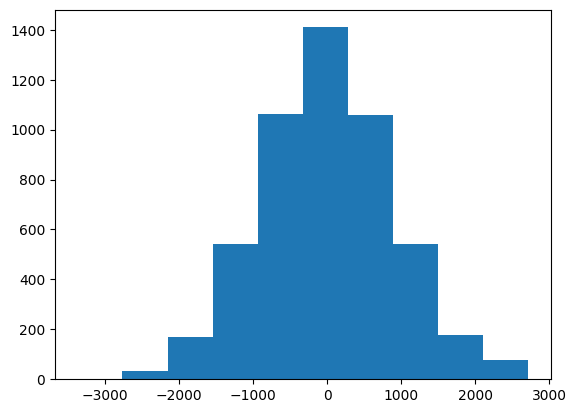

In [5]:
import matplotlib.pyplot as plt
plt.hist(dict_delay[pd.Timestamp("2025-01-02")]["D1_orth"])
plt.show()


In [6]:
desdir = "E:/SJTU/实习/国泰海通/业绩回测/nav"

target = ["000922.XSHG","H00922.INDX"] #红利指数、红利全收益指数
#target = ['000300.XSHG','000905.XSHG', '000852.XSHG','000510.XSHG','932000.INDX']
sd = "20250101"
ed = "20260428"
temp = get_price_change_rate(target, start_date=sd, end_date=ed, expect_df=True, market='cn')
#get_auction_info("000922.XSHG", start_date=sd, end_date=ed, frequency='1d', market='cn') #688012.XSHG
nav = (1 + temp).cumprod()
nav = nav / nav.iloc[0]
nav.to_excel(f"{desdir}/nav_index.xlsx")

In [4]:

import pandas as pd

srcdir = "E:/SJTU/实习/国泰海通/业绩回测/nav"
oridir = "E:/SJTU/实习/国泰海通/barra因子/data_base/fund_nav"
nav_df = pd.read_excel(f"{srcdir}/pure_alpha_ranking.xlsx",index_col=0)
ori_nav = pd.read_excel(f"{oridir}/中证500净值数据.xlsx",index_col=0)


ori_df = ori_nav.pct_change().reset_index()
# 保留date列，其他所有列（fund1,fund2...）都转成 fund + 收益率
ori_long = ori_df.melt(
    id_vars="date",        # 以date作为主键
    var_name="fund",       # 原列名（fund1）变成 fund 列的值
    value_name="fund_ret"  # 收益率数据放到 fund_ret 列
)

# ----------------------
# 2. 合并到 nav_df（按 date + fund 精准匹配）
# ----------------------
# 左连接：保留nav_df所有行，匹配上的填入fund_ret
nav_df_final = pd.merge(
    nav_df,
    ori_long,
    on=["date", "fund"],   # 双主键匹配，最精准
    how="left"             # 不丢失nav_df原有数据
)

# ----------------------
# 可选：检查是否有缺失（方便你排查数据问题）
# ----------------------
missing_count = nav_df_final["fund_ret"].isna().sum()
print(f"匹配缺失数量：{missing_count}")
if missing_count > 0:
    print("可能原因：日期不匹配 / fund名称大小写/空格不一致 / ori_df缺少该基金")

匹配缺失数量：0


C:\Windows\Temp\ipykernel_93284\2689012819.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ori_df = ori_nav.pct_change().reset_index()


In [8]:
nav_df_final.to_excel(f"{srcdir}/barra_alpha_ret.xlsx")